In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
from sklearn.preprocessing import LabelEncoder, StandardScaler , OneHotEncoder
from sklearn.model_selection import train_test_split



from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# Evaluation Metrics 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 
import warnings

# to Suppress future warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### Reading the Data

In [104]:
df=pd.read_csv("feed.csv")
df

,created_at,entry_id,field1,field2,field3,field4,field5,field6
0,2025-11-19T04:56:14+00:00,1,464,0,0.000000,0.000000,19-11-2025 10:26:13,0.0
1,2025-11-19T04:56:31+00:00,2,482,0,0.000000,0.000000,19-11-2025 10:26:30,0.0
2,2025-11-19T04:56:48+00:00,3,493,0,0.000000,0.000000,19-11-2025 10:26:47,0.0
3,2025-11-19T04:57:04+00:00,4,487,0,0.000000,0.000000,19-11-2025 10:27:04,0.0
4,2025-11-19T04:57:22+00:00,5,581,5,0.000000,0.000000,19-11-2025 10:27:20,1.0
...,...,...,...,...,...,...,...,...
727,2025-11-19T16:34:55+00:00,728,954,30,16.744922,74.275054,19-11-2025 22:04:53,1.0
728,2025-11-19T16:35:12+00:00,729,927,28,16.744922,74.275064,19-11-2025 22:05:10,1.0
729,2025-11-19T16:35:28+00:00,730,898,26,16.744930,74.275065,19-11-2025 22:05:27,1.0
730,2025-11-19T16:35:45+00:00,731,886,25,16.744928,74.275078,19-11-2025 22:05:43,1.0


In [105]:
print("Dataset Loaded Successfully!")
print(df.head())

Dataset Loaded Successfully!
                  created_at  entry_id  field1  field2  field3  field4  \
0  2025-11-19T04:56:14+00:00         1     464       0     0.0     0.0   
1  2025-11-19T04:56:31+00:00         2     482       0     0.0     0.0   
2  2025-11-19T04:56:48+00:00         3     493       0     0.0     0.0   
3  2025-11-19T04:57:04+00:00         4     487       0     0.0     0.0   
4  2025-11-19T04:57:22+00:00         5     581       5     0.0     0.0   

                field5  field6  
0  19-11-2025 10:26:13     0.0  
1  19-11-2025 10:26:30     0.0  
2  19-11-2025 10:26:47     0.0  
3  19-11-2025 10:27:04     0.0  
4  19-11-2025 10:27:20     1.0  


### Rename Column

In [106]:
df.columns = [
    "timestamp",
    "entry_id",
    "mq2_value",
    "alcohol_percentage",
    "latitude",
    "longitude",
    "timestamp",
    "drunk_Status"
]
print(df.columns)

Index(['timestamp', 'entry_id', 'mq2_value', 'alcohol_percentage', 'latitude',
       'longitude', 'timestamp', 'drunk_Status'],
      dtype='object')


In [107]:
df=df.drop(['entry_id','timestamp'],axis=1)
df

,mq2_value,alcohol_percentage,latitude,longitude,drunk_Status
0,464,0,0.000000,0.000000,0.0
1,482,0,0.000000,0.000000,0.0
2,493,0,0.000000,0.000000,0.0
3,487,0,0.000000,0.000000,0.0
4,581,5,0.000000,0.000000,1.0
...,...,...,...,...,...
727,954,30,16.744922,74.275054,1.0
728,927,28,16.744922,74.275064,1.0
729,898,26,16.744930,74.275065,1.0
730,886,25,16.744928,74.275078,1.0


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mq2_value           732 non-null    int64  
 1   alcohol_percentage  732 non-null    int64  
 2   latitude            732 non-null    float64
 3   longitude           732 non-null    float64
 4   drunk_Status        731 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 28.7 KB


In [109]:
df['latitude'].mean()

np.float64(8.372484094262296)

In [110]:
df['latitude']=df['latitude'].fillna(df['latitude'].mean())
df

,mq2_value,alcohol_percentage,latitude,longitude,drunk_Status
0,464,0,0.000000,0.000000,0.0
1,482,0,0.000000,0.000000,0.0
2,493,0,0.000000,0.000000,0.0
3,487,0,0.000000,0.000000,0.0
4,581,5,0.000000,0.000000,1.0
...,...,...,...,...,...
727,954,30,16.744922,74.275054,1.0
728,927,28,16.744922,74.275064,1.0
729,898,26,16.744930,74.275065,1.0
730,886,25,16.744928,74.275078,1.0


In [111]:
df['longitude'].mean()

np.float64(37.03624075)

In [112]:
df['longitude']=df['longitude'].fillna(df['longitude'].mean())
df

,mq2_value,alcohol_percentage,latitude,longitude,drunk_Status
0,464,0,0.000000,0.000000,0.0
1,482,0,0.000000,0.000000,0.0
2,493,0,0.000000,0.000000,0.0
3,487,0,0.000000,0.000000,0.0
4,581,5,0.000000,0.000000,1.0
...,...,...,...,...,...
727,954,30,16.744922,74.275054,1.0
728,927,28,16.744922,74.275064,1.0
729,898,26,16.744930,74.275065,1.0
730,886,25,16.744928,74.275078,1.0


In [113]:
df['drunk_Status'].mode()

0    1.0
Name: drunk_Status, dtype: float64

In [114]:
df['drunk_Status'].unique()

array([ 0.,  1., nan])

In [115]:
df['drunk_Status'].value_counts()

drunk_Status
1.0    607
0.0    124
Name: count, dtype: int64

In [116]:
df['drunk_Status']=df['drunk_Status'].replace(np.nan,1)
df

,mq2_value,alcohol_percentage,latitude,longitude,drunk_Status
0,464,0,0.000000,0.000000,0.0
1,482,0,0.000000,0.000000,0.0
2,493,0,0.000000,0.000000,0.0
3,487,0,0.000000,0.000000,0.0
4,581,5,0.000000,0.000000,1.0
...,...,...,...,...,...
727,954,30,16.744922,74.275054,1.0
728,927,28,16.744922,74.275064,1.0
729,898,26,16.744930,74.275065,1.0
730,886,25,16.744928,74.275078,1.0


In [117]:
df.isnull().sum()


mq2_value             0
alcohol_percentage    0
latitude              0
longitude             0
drunk_Status          0
dtype: int64

In [118]:
df.corr()

,mq2_value,alcohol_percentage,latitude,longitude,drunk_Status
mq2_value,1.000000,0.946104,0.301792,0.299537,0.408333
alcohol_percentage,0.946104,1.000000,0.350279,0.346624,0.381503
latitude,0.301792,0.350279,1.000000,0.997280,0.131111
longitude,0.299537,0.346624,0.997280,1.000000,0.129880
drunk_Status,0.408333,0.381503,0.131111,0.129880,1.000000


<Axes: >

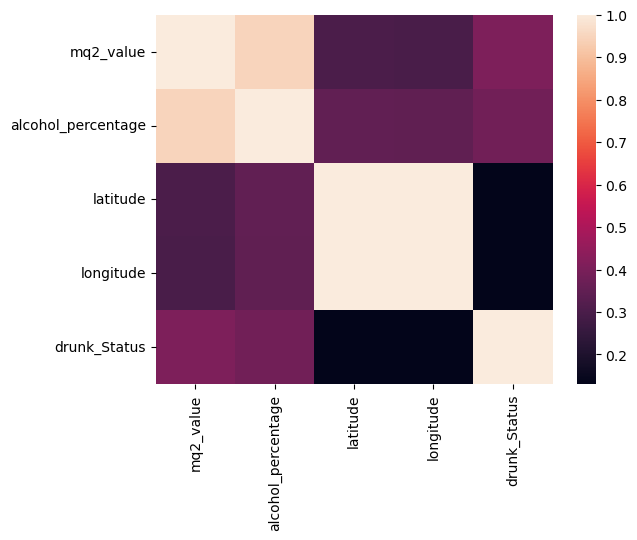

In [119]:
sns.heatmap(df.corr())

### Model Building

In [120]:
y=df['drunk_Status']
x=df.drop('drunk_Status',axis=1)

In [121]:
x.shape,y.shape

((732, 4), (732,))

In [122]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

In [123]:
x_train.shape,x_test.shape

((658, 4), (74, 4))

In [124]:
y_train.shape,y_test.shape

((658,), (74,))

In [125]:
scaler = StandardScaler()

In [126]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [127]:
y_test_int = y_test.astype(int)       # ensure binary labels are integers
y_pred_int = y_pred.astype(int)       # convert predicted labels to int


## Model 1: Logistic Regression

In [128]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)

print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Logistic Regression Results:
Accuracy: 0.9864864864864865
              precision    recall  f1-score   support

         0.0       1.00      0.91      0.95        11
         1.0       0.98      1.00      0.99        63

    accuracy                           0.99        74
   macro avg       0.99      0.95      0.97        74
weighted avg       0.99      0.99      0.99        74

[[10  1]
 [ 0 63]]


## Model 2:Decision Tree

In [129]:
model = RandomForestClassifier(n_estimators=1000, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Random Forest Results:
Accuracy: 1.0
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        11
         1.0       1.00      1.00      1.00        63

    accuracy                           1.00        74
   macro avg       1.00      1.00      1.00        74
weighted avg       1.00      1.00      1.00        74

[[11  0]
 [ 0 63]]


## Model 3:Random Forest

In [130]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Random Forest Results:
Accuracy: 1.0
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        11
         1.0       1.00      1.00      1.00        63

    accuracy                           1.00        74
   macro avg       1.00      1.00      1.00        74
weighted avg       1.00      1.00      1.00        74

[[11  0]
 [ 0 63]]


## Model 4:K-Nearest Neighbors (KNN)

In [131]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)

print("KNN Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

KNN Results:
Accuracy: 0.9864864864864865
              precision    recall  f1-score   support

         0.0       1.00      0.91      0.95        11
         1.0       0.98      1.00      0.99        63

    accuracy                           0.99        74
   macro avg       0.99      0.95      0.97        74
weighted avg       0.99      0.99      0.99        74

[[10  1]
 [ 0 63]]


In [132]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.9865

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.91      0.95        11
         1.0       0.98      1.00      0.99        63

    accuracy                           0.99        74
   macro avg       0.99      0.95      0.97        74
weighted avg       0.99      0.99      0.99        74

Confusion Matrix:
[[10  1]
 [ 0 63]]


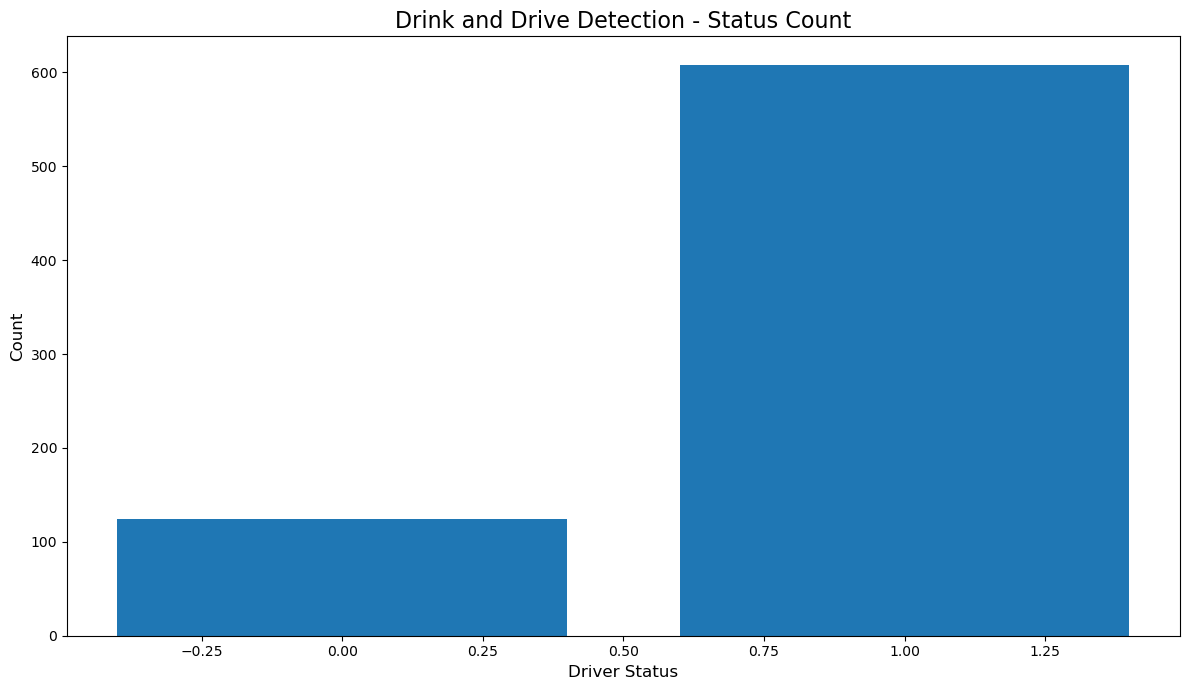

In [135]:

# Count values of drunk status
drunk_counts = df['drunk_Status'].value_counts().sort_values(ascending=False)

# Plot the bar chart
plt.figure(figsize=(12, 7))
plt.bar(drunk_counts.index, drunk_counts.values)

plt.title('Drink and Drive Detection - Status Count', fontsize=16)
plt.xlabel('Driver Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


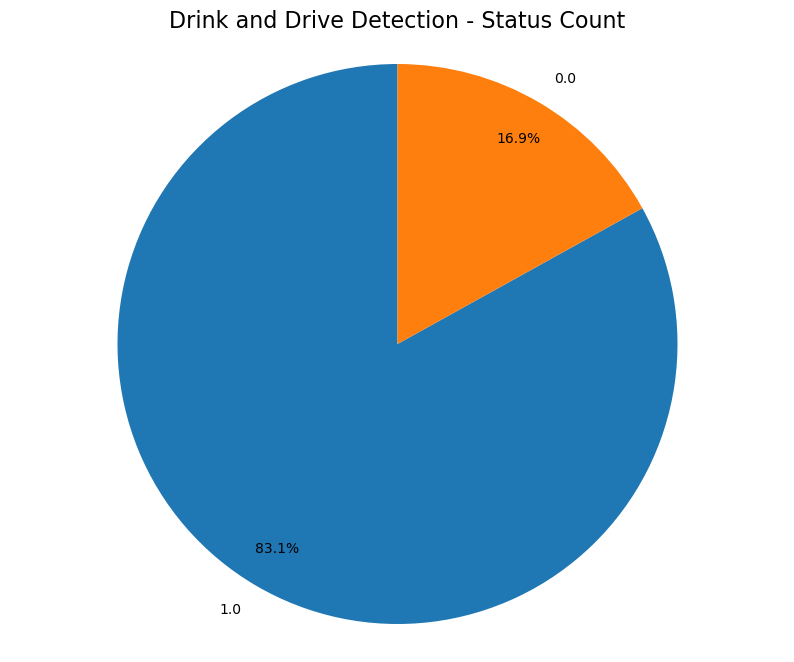

In [136]:

status_counts = df['drunk_Status'].value_counts()

# Create the pie chart
plt.figure(figsize=(10, 8))
plt.pie(status_counts, 
        labels=status_counts.index, 
        autopct='%1.1f%%',  # This adds the percentage labels
        startangle=90,
        pctdistance=0.85) # Moves percentages inside

# Add a title
plt.title('Drink and Drive Detection - Status Count', fontsize=16)
plt.axis('equal')  
plt.show()